# Estandarización Semántica, Modelado Ontológico (OGC GeoSciML, W3C PROV-O, CIDOC-CRM) y Creación de Sub-datasets de Minería Romana en España (OxREP)
### *Infraestructura de Datos Arqueomineros, Matriz de Certeza Epistemológica y Preparación de Evidencias para Modelos GeoAI de Prospectividad Mineral*

---

## 🏛️ Contexto Científico, Metodológico y Metalogénico

### 1. La Minería Romana como Proxy Histórico de Sistemas Mineralizantes
En el marco de la **prospectividad mineral asistida por Inteligencia Artificial (Mineral Prospectivity Mapping - MPM / GeoAI)**, las evidencias de explotaciones mineras antiguas no son meros puntos arqueológicos de interés patrimonial, sino **observaciones históricas directas de mineralizaciones superficiales o sub-superficiales** que fueron lo suficientemente concentradas, accesibles y rentables como para justificar su extracción a gran escala por la ingeniería romana.

Como establece el documento marco *«Modelo GeoAI de Prospectividad Mineral en España»*:
> **Principio Metodológico:** La mina romana no se plantea como una variable predictora $X$, sino como una fuente de evidencia empírica para construir la variable objetivo $Y$ (etiqueta positiva de mineralización) en el modelo histórico $P(\text{Minería Romana} \mid X_{\text{geocientíficas}})$.

### 2. Estándares Ontológicos Integrados
Para transformar una hoja de cálculo tabular (`oxrep-mines-3.0`) en una infraestructura de conocimiento trazable e interoperable, este cuaderno implementa la convergencia de cuatro estándares internacionales:

```
┌─────────────────────────────────────────────────────────────────────────────────────────────────┐
│                           ARQUITECTURA ONTOLÓGICA GEOAI MULTI-ESTÁNDAR                          │
├───────────────────────────────┬─────────────────────────────────┬───────────────────────────────┤
│    OGC GeoSciML v4.1          │    CIDOC-CRM v7.1 (ISO 21127)   │    W3C PROV-O & SOSA/SSN      │
│  (Dominio Geocientífico)      │   (Dominio Arqueo-Patrimonial)  │  (Procedencia y Observaciones) │
├───────────────────────────────┼─────────────────────────────────┼───────────────────────────────┤
│ • gsml:MineralOccurrence      │ • crm:E22_Human-Made_Object     │ • prov:wasDerivedFrom         │
│ • gsml:Commodity (Au, Ag...)  │ • crm:E7_Activity (Mining)      │ • prov:wasAttributedTo (Auth) │
│ • gsml:MiningActivity         │ • crm:E53_Place / E52_Time-Span │ • sosa:Observation           │
│ • gsml:EarthMaterial          │ • crm:E55_Type (Técnicas)       │ • qudt:QuantityValue (Metros) │
└───────────────────────────────┴─────────────────────────────────┴───────────────────────────────┘
```

### 3. Objetivos de este Cuaderno
1. **Auditar e Ingerir** el dataset internacional de minas romanas del *Oxford Roman Economy Project (OxREP v3.0)*.
2. **Estandarizar Vocabularios Controlados** para commodities minerales, técnicas de beneficio (*Ruina Montium*, galerías subterráneas, cortas, placeres) y divisiones administrativas romanas (*Hispania Citerior / Tarraconensis, Baetica, Lusitania*).
3. **Calibrar la Matriz de Certeza Epistemológica** ($C_{\text{geo}}, C_{\text{arq}}, C_{\text{met}}$) para evitar entrenar modelos con coordenadas espurias o asignaciones dudosas.
4. **Generar y Exportar Sub-datasets Geoespaciales Especializados** (GeoJSON, GeoPackage multi-capa EPSG:25830 y CSV enriquecido) por commodity y por técnica.
5. **Construir el Grafo Semántico de Conocimiento en Formato Linked Open Data (JSON-LD)** combinando CIDOC-CRM y GeoSciML.
6. **Generar Cartografía Interactiva Web** para inspección visual y diagnóstico espacial.

In [1]:
# ==============================================================================
# 1. Configuración del Entorno, Librerías y Parámetros del Proyecto
# ==============================================================================
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
import folium
from folium.plugins import MarkerCluster, FeatureGroupSubGroup

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Definición de Rutas Reproducibles
PROJECT_ROOT = os.path.abspath("..") if os.path.exists("../data") else os.path.abspath(".")
RAW_DATA_PATH = os.path.join(PROJECT_ROOT, "data", "raw", "oxrep-mines-3.0-20250408.xlsx")
PROCESSED_DATA_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

# Sistemas de Coordenadas de Referencia (CRS)
CRS_WGS84 = "EPSG:4326"        # Coordenadas geográficas globales (lat/lon)
CRS_SPAIN_ETRS89 = "EPSG:25830" # Proyección métrica oficial de España (UTM Huso 30N)

print(" Entorno configurado correctamente.")
print(f"📁 Ruta del proyecto: {PROJECT_ROOT}")
print(f"📁 Archivo de entrada: {RAW_DATA_PATH}")
print(f"📁 Directorio de salida: {PROCESSED_DATA_DIR}")

 Entorno configurado correctamente.
📁 Ruta del proyecto: c:\Users\mdmat\Desktop\Recursos Curso EOI\geoai-mineria-romana-espana
📁 Archivo de entrada: c:\Users\mdmat\Desktop\Recursos Curso EOI\geoai-mineria-romana-espana\data\raw\oxrep-mines-3.0-20250408.xlsx
📁 Directorio de salida: c:\Users\mdmat\Desktop\Recursos Curso EOI\geoai-mineria-romana-espana\data\processed


---
## 1. Carga, Auditoría y Diagnóstico del Dataset OxREP v3.0

Cargamos la base de datos oficial del *Oxford Roman Economy Project (OxREP)* y realizamos una auditoría inicial de registros a escala del Imperio Romano y a escala de **Hispania (España y Portugal)**.

In [2]:
# ==============================================================================
# 1.1 Ingesta y Diagnóstico General de OxREP v3.0
# ==============================================================================
if not os.path.exists(RAW_DATA_PATH):
    # Fallback por si se ejecuta desde otra carpeta
    alt_path = os.path.join("c:\\Users\\mdmat\\Desktop\\Recursos Curso EOI\\oxrep-mines-3.0-20250408.xlsx")
    if os.path.exists(alt_path):
        RAW_DATA_PATH = alt_path

df_raw = pd.read_excel(RAW_DATA_PATH)
print(f" Dimensiones globales de OxREP v3.0: {df_raw.shape[0]} explotaciones mineras x {df_raw.shape[1]} atributos")

# Filtrado de la Península Ibérica / Hispania
df_hispania = df_raw[df_raw['country'].isin(['Spain', 'Portugal'])].copy()
print(f" Registros en Hispania: {len(df_hispania)} minas ({len(df_hispania)/len(df_raw)*100:.1f}% del total del Imperio Romano)")
print(f"   • España (Hispania Citerior & Baetica): {len(df_raw[df_raw['country']=='Spain'])} minas")
print(f"   • Portugal (Lusitania occidental): {len(df_raw[df_raw['country']=='Portugal'])} minas")

# Comprobación de coordenadas espaciales
df_hispania = df_hispania[df_hispania['latitude'].notnull() & df_hispania['longitude'].notnull()].copy()
print(f" Registros con coordenadas válidas: {len(df_hispania)} minas")

 Dimensiones globales de OxREP v3.0: 1399 explotaciones mineras x 47 atributos
 Registros en Hispania: 1001 minas (71.6% del total del Imperio Romano)
   • España (Hispania Citerior & Baetica): 929 minas
   • Portugal (Lusitania occidental): 72 minas
 Registros con coordenadas válidas: 993 minas


In [3]:
# ==============================================================================
# 1.2 Vista Previa de Columnas y Muestra de Datos
# ==============================================================================
display_cols = ['mineID', 'site', 'ancientName', 'province', 'country', 'region', 
                'miningDistrict', 'latitude', 'longitude', 'coordinateAccuracy',
                'metalMinedGold', 'metalMinedSilver', 'metalMinedCopper', 'metalMinedLead',
                'techniqueRuinaMontium', 'techniqueUnderground', 'references']

print(" Muestra de las 5 primeras explotaciones en Hispania:")
display(df_hispania[display_cols].head())

 Muestra de las 5 primeras explotaciones en Hispania:


,mineID,site,ancientName,province,country,region,miningDistrict,latitude,longitude,coordinateAccuracy,metalMinedGold,metalMinedSilver,metalMinedCopper,metalMinedLead,techniqueRuinaMontium,techniqueUnderground,references
0,1,Aljustrel,Vipasca,Lusitania,Portugal,Beja,Alentejo,37.880874,-8.175981,1000.0,?,1.0,1.0,0.0,0.0,1.0,Domergue 1983: 5-193; Domergue 1990: 62
1,2,Atalaia de Alte,NaN,Lusitania,Portugal,Faro,Algarve,37.243152,-8.187165,NaN,FALSE,0.0,1.0,0.0,0.0,NaN,Domergue 1990: 62
2,3,Avintes,NaN,Lusitania,Portugal,Northern Portugal,Northern Portugal,41.099158,-8.544675,1000.0,TRUE,0.0,0.0,0.0,0.0,NaN,"Sanchez-Palencia and Orejas 1994, 198"
3,4,Belmonte - Colmeal - Maçainhas,NaN,Hispania Tarraconensis,Portugal,Castelo Branco,Trás-os-montes,40.389638,-7.340494,NaN,FALSE,0.0,0.0,0.0,0.0,NaN,Domergue 1990: 41
4,5,Brancanes,NaN,Lusitania,Portugal,Beja,Alentejo,37.557563,-8.016501,NaN,FALSE,0.0,1.0,0.0,0.0,1.0,Domergue 1990: 62


---
## 2. Definición Formal de Vocabularios Controlados y Ontologías (Linked Open Data)

Implementamos la estructura formal de conceptos alineada con **OGC GeoSciML v4.1**, **CGI Controlled Vocabularies**, **CIDOC-CRM v7.1** y **W3C PROV-O**.

In [4]:
# ==============================================================================
# 2.1 Tesauro de Commodities Minerales (OGC GeoSciML & CGI Vocabularies)
# ==============================================================================
COMMODITY_ONTOLOGY = {
    'Au_Oro': {
        'column': 'metalMinedGold',
        'label_es': 'Oro',
        'label_en': 'Gold',
        'symbol': 'Au',
        'atomic_number': 79,
        'geosciml_uri': 'http://resource.geosciml.org/classifier/cgi/commodity-code/gold',
        'wikidata_uri': 'https://www.wikidata.org/wiki/Q208045',
        'crm_type_uri': 'http://purl.org/heritagedata/schemes/eh_tmt2/concepts/gold_mine',
        'marker_color': '#D4AF37',  # Oro metálico
        'marker_icon': 'certificate',
        'category': 'PreciousMetal',
        'strategic_relevance': 'HighEconomic'
    },
    'Ag_Plata': {
        'column': 'metalMinedSilver',
        'label_es': 'Plata',
        'label_en': 'Silver',
        'symbol': 'Ag',
        'atomic_number': 47,
        'geosciml_uri': 'http://resource.geosciml.org/classifier/cgi/commodity-code/silver',
        'wikidata_uri': 'https://www.wikidata.org/wiki/Q1090',
        'crm_type_uri': 'http://purl.org/heritagedata/schemes/eh_tmt2/concepts/silver_mine',
        'marker_color': '#A8A9AD',  # Plata
        'marker_icon': 'star',
        'category': 'PreciousMetal',
        'strategic_relevance': 'HighEconomic'
    },
    'Cu_Cobre': {
        'column': 'metalMinedCopper',
        'label_es': 'Cobre',
        'label_en': 'Copper',
        'symbol': 'Cu',
        'atomic_number': 29,
        'geosciml_uri': 'http://resource.geosciml.org/classifier/cgi/commodity-code/copper',
        'wikidata_uri': 'https://www.wikidata.org/wiki/Q753',
        'crm_type_uri': 'http://purl.org/heritagedata/schemes/eh_tmt2/concepts/copper_mine',
        'marker_color': '#B87333',  # Cobre
        'marker_icon': 'bolt',
        'category': 'BaseMetal',
        'strategic_relevance': 'CriticalStrategic_EU'
    },
    'Pb_Plomo': {
        'column': 'metalMinedLead',
        'label_es': 'Plomo',
        'label_en': 'Lead',
        'symbol': 'Pb',
        'atomic_number': 82,
        'geosciml_uri': 'http://resource.geosciml.org/classifier/cgi/commodity-code/lead',
        'wikidata_uri': 'https://www.wikidata.org/wiki/Q708',
        'crm_type_uri': 'http://purl.org/heritagedata/schemes/eh_tmt2/concepts/lead_mine',
        'marker_color': '#4A5568',  # Gris plomo
        'marker_icon': 'wrench',
        'category': 'BaseMetal',
        'strategic_relevance': 'Industrial'
    },
    'Hg_Cinabrio': {
        'column': 'metalMinedMercuryCinnabar',
        'label_es': 'Mercurio / Cinabrio',
        'label_en': 'Mercury / Cinnabar',
        'symbol': 'Hg',
        'atomic_number': 80,
        'geosciml_uri': 'http://resource.geosciml.org/classifier/cgi/commodity-code/mercury',
        'wikidata_uri': 'https://www.wikidata.org/wiki/Q925',
        'crm_type_uri': 'http://purl.org/heritagedata/schemes/eh_tmt2/concepts/cinnabar_mine',
        'marker_color': '#E53E3E',  # Rojo cinabrio
        'marker_icon': 'fire',
        'category': 'SpecialMetal',
        'strategic_relevance': 'HistoricalMonopoly'
    },
    'Sn_Estano': {
        'column': 'metalMinedTin',
        'label_es': 'Estaño / Casiterita',
        'label_en': 'Tin',
        'symbol': 'Sn',
        'atomic_number': 50,
        'geosciml_uri': 'http://resource.geosciml.org/classifier/cgi/commodity-code/tin',
        'wikidata_uri': 'https://www.wikidata.org/wiki/Q1096',
        'crm_type_uri': 'http://purl.org/heritagedata/schemes/eh_tmt2/concepts/tin_mine',
        'marker_color': '#718096',
        'marker_icon': 'cog',
        'category': 'StrategicAlloy',
        'strategic_relevance': 'CriticalStrategic_EU'
    },
    'Fe_Hierro': {
        'column': 'metalMinedIron',
        'label_es': 'Hierro',
        'label_en': 'Iron',
        'symbol': 'Fe',
        'atomic_number': 26,
        'geosciml_uri': 'http://resource.geosciml.org/classifier/cgi/commodity-code/iron',
        'wikidata_uri': 'https://www.wikidata.org/wiki/Q677',
        'crm_type_uri': 'http://purl.org/heritagedata/schemes/eh_tmt2/concepts/iron_mine',
        'marker_color': '#2D3748',
        'marker_icon': 'shield',
        'category': 'IndustrialFerrous',
        'strategic_relevance': 'Industrial'
    }
}

print(f" Tesauro OGC GeoSciML formalizado: {len(COMMODITY_ONTOLOGY)} commodities metalíferos.")

 Tesauro OGC GeoSciML formalizado: 7 commodities metalíferos.


In [5]:
# ==============================================================================
# 2.2 Tesauro de Técnicas de Explotación Minera Romana (CIDOC-CRM & Plinio)
# ==============================================================================
MINING_TECHNIQUES_ONTOLOGY = {
    'Ruina_Montium': {
        'columns': ['techniqueRuinaMontium', 'techniqueHydraulic', 'techniqueHushing', 'techniqueGroundSluicing'],
        'label_es': 'Ruina Montium (Minería Hidráulica / Hushing)',
        'label_en': 'Hydraulic Mining (Ruina Montium)',
        'historical_source': 'Plinio el Viejo (Naturalis Historia XXXIII, 70-73)',
        'crm_activity_uri': 'http://vocab.getty.edu/aat/300053913',
        'geomorphological_signature': 'Grandes zanjas de desagüe, cortas de hundimiento y red de canales'
    },
    'Subterranea': {
        'columns': ['techniqueUnderground'],
        'label_es': 'Minería Subterránea (Pozos y Galerías con Entibación)',
        'label_en': 'Underground Mining (Shafts and Galleries)',
        'historical_source': 'Plinio / Estrabón / Tablas de Aljustrel (Lex Metallis Dicta)',
        'crm_activity_uri': 'http://vocab.getty.edu/aat/300053915',
        'geomorphological_signature': 'Pozos verticales (putei), galerías de drenaje (socavones) y tornillos de Arquímedes'
    },
    'Cielo_Abierto': {
        'columns': ['techniqueOpencast', 'techniqueRakeComb'],
        'label_es': 'Corta y Explotación a Cielo Abierto',
        'label_en': 'Opencast / Surface Quarrying',
        'historical_source': 'Diodoro Sículo / Arqueología de Campo',
        'crm_activity_uri': 'http://vocab.getty.edu/aat/300053914',
        'geomorphological_signature': 'Trincheras lineales sobre filones en superficie y zanjas de prospección'
    },
    'Lavado_Placer': {
        'columns': ['techniqueGoldWashing'],
        'label_es': 'Lavado de Placeres Aluviales',
        'label_en': 'Alluvial Placer Washing',
        'historical_source': 'Estrabón (Geographica III)',
        'crm_activity_uri': 'http://vocab.getty.edu/aat/300053916',
        'geomorphological_signature': 'Terrazas fluviales auríferas (aurífera auraria) con montones de cantos (murias)'
    }
}

print(f" Tesauro de técnicas mineras romanas formalizado: {len(MINING_TECHNIQUES_ONTOLOGY)} tipologías tecnológicas.")

 Tesauro de técnicas mineras romanas formalizado: 4 tipologías tecnológicas.


---
## 3. Motor de Normalización y Matriz de Certeza Epistemológica

Uno de los principales riesgos en Ciencia de Datos Arqueológicos es tratar con igual peso observaciones verificadas mediante excavación y fechadas epigráficamente frente a coordenadas aproximadas basadas en toponimia.

Implementamos un **algoritmo de evaluación epistemológica tridimensional**:

$$C_{\text{Total}} = 0.40 \cdot C_{\text{Geo}} + 0.35 \cdot C_{\text{Arq}} + 0.25 \cdot C_{\text{Met}}$$

* **$C_{\text{Geo}}$ (Certeza Espacial):** Calibrada según el radio de error reportado (`coordinateAccuracy`):
  - $\le 100\text{ m} \rightarrow 1.0$ (Coordenada GPS / Fotogrametría exacta).
  - $100\text{ m} < \text{acc} \le 500\text{ m} \rightarrow 0.85$ (Levantamiento topográfico MTN50).
  - $500\text{ m} < \text{acc} \le 1000\text{ m} \rightarrow 0.70$ (Localización a nivel de paraje).
  - $> 1000\text{ m} \text{ o nula} \rightarrow 0.40$ (Aproximación por municipio).
* **$C_{\text{Arq}}$ (Certeza Arqueológica):** Calibrada por la autoridad y tipo de fuente:
  - Referencias clásicas monográficas directas (Domergue 1990, Sánchez-Palencia & Orejas 1994, Hirt 2010) $\rightarrow 1.0$.
  - Menciones bibliográficas secundarias $\rightarrow 0.75$.
  - Sin referencia detallada $\rightarrow 0.40$.
* **$C_{\text{Met}}$ (Certeza Metalogénica):** Calibrada por el grado de confirmación de los metales:
  - Metal confirmado (`1.0` / `'TRUE'`) $\rightarrow 1.0$.
  - Metal hipotético (`'?'`) $\rightarrow 0.50$.

In [6]:
# ==============================================================================
# 3.1 Funciones de Normalización y Cálculo de Certeza
# ==============================================================================
def parse_flag(val):
    if pd.isnull(val):
        return 0, 'No'
    s = str(val).strip().upper()
    if s in ['1', '1.0', 'TRUE', 'T', 'YES', 'Y']:
        return 1, 'Confirmado'
    elif s in ['?', 'UNCERTAIN', 'PROBABLE', 'MAYBE']:
        return 1, 'Hipotetico'
    else:
        return 0, 'No'

# Normalización de variables de commodity
for key, meta in COMMODITY_ONTOLOGY.items():
    col = meta['column']
    if col in df_hispania.columns:
        parsed = df_hispania[col].apply(parse_flag)
        df_hispania[f'Flag_{key}'] = parsed.apply(lambda x: x[0])
        df_hispania[f'Status_{key}'] = parsed.apply(lambda x: x[1])

# Normalización de técnicas de minería
for tech_key, tech_meta in MINING_TECHNIQUES_ONTOLOGY.items():
    cols = tech_meta['columns']
    # Una mina utiliza la técnica si alguna de sus columnas asociadas es 1/TRUE
    tech_flags = df_hispania[cols].apply(lambda row: max([parse_flag(v)[0] for v in row]), axis=1)
    df_hispania[f'Tech_{tech_key}'] = tech_flags

# ==============================================================================
# 3.2 Cálculo de la Matriz de Certeza Epistemológica
# ==============================================================================
def compute_spatial_certainty(acc):
    if pd.isnull(acc):
        return 0.50
    try:
        acc_m = float(acc)
        if acc_m <= 100:
            return 1.00
        elif acc_m <= 500:
            return 0.85
        elif acc_m <= 1000:
            return 0.70
        elif acc_m <= 5000:
            return 0.50
        else:
            return 0.30
    except:
        return 0.50

def compute_archaeological_certainty(row):
    score = 0.40
    refs = str(row.get('references', '')).lower()
    domergue = str(row.get('domergueID', ''))
    sanchez = str(row.get('sanchezPalenciaAndOrejasID', ''))
    
    if domergue != 'nan' and len(domergue.strip()) > 0:
        score += 0.30
    if sanchez != 'nan' and len(sanchez.strip()) > 0:
        score += 0.30
    if 'domergue' in refs or 'sánchez-palencia' in refs or 'palencia' in refs or 'orejas' in refs:
        score = max(score, 0.90)
    elif len(refs) > 10:
        score = max(score, 0.75)
        
    return min(score, 1.00)

def compute_metallogenic_certainty(row):
    statuses = [row.get(f'Status_{k}') for k in COMMODITY_ONTOLOGY.keys()]
    if 'Confirmado' in statuses:
        return 1.00
    elif 'Hipotetico' in statuses:
        return 0.60
    else:
        return 0.40

df_hispania['Certainty_Spatial'] = df_hispania['coordinateAccuracy'].apply(compute_spatial_certainty)
df_hispania['Certainty_Archaeological'] = df_hispania.apply(compute_archaeological_certainty, axis=1)
df_hispania['Certainty_Metallogenic'] = df_hispania.apply(compute_metallogenic_certainty, axis=1)

# Puntuación global ponderada
df_hispania['Certainty_Score'] = (
    0.40 * df_hispania['Certainty_Spatial'] +
    0.35 * df_hispania['Certainty_Archaeological'] +
    0.25 * df_hispania['Certainty_Metallogenic']
)

def classify_certainty_grade(score):
    if score >= 0.80:
        return 'Alta Certeza (Grado I)'
    elif score >= 0.60:
        return 'Media Certeza (Grado II)'
    else:
        return 'Baja Certeza / Exploratoria (Grado III)'

df_hispania['Certainty_Grade'] = df_hispania['Certainty_Score'].apply(classify_certainty_grade)

print(" Matriz de Certeza Epistemológica calculada:")
print(df_hispania['Certainty_Grade'].value_counts(dropna=False))

 Matriz de Certeza Epistemológica calculada:
Certainty_Grade
Alta Certeza (Grado I)                     903
Media Certeza (Grado II)                    87
Baja Certeza / Exploratoria (Grado III)      3
Name: count, dtype: int64


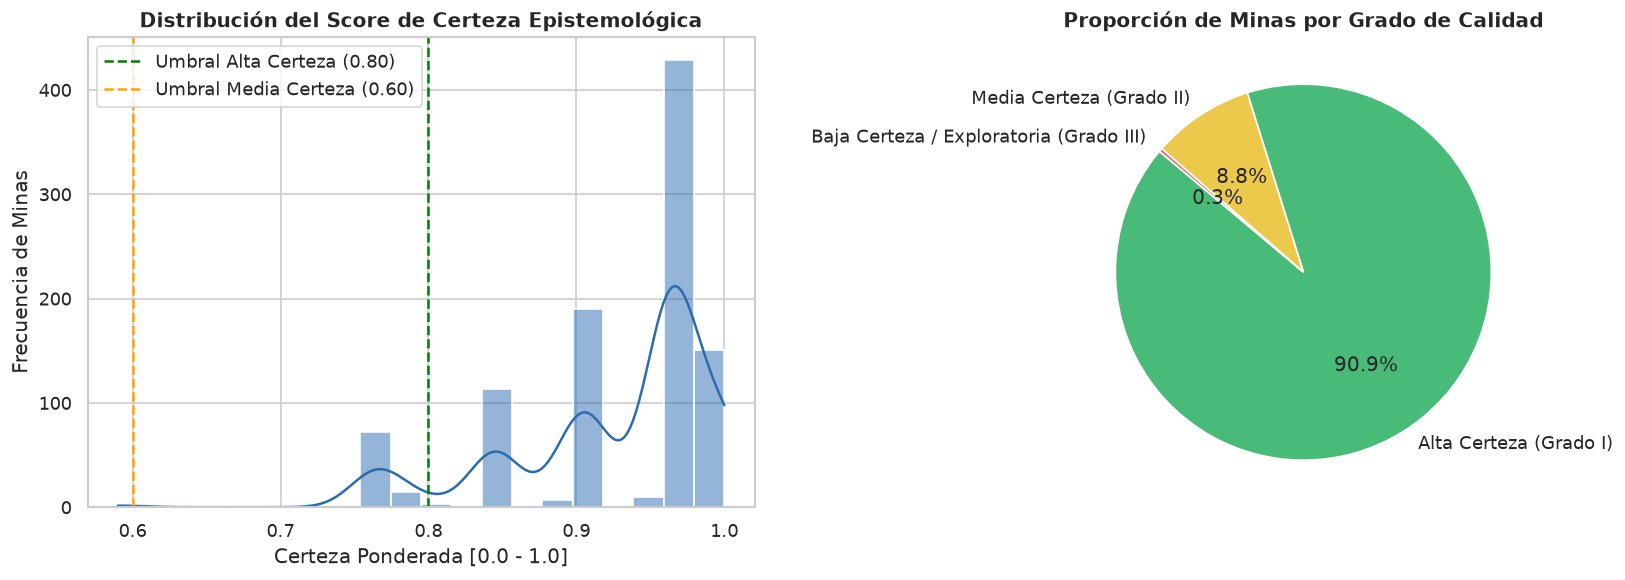

In [7]:
# ==============================================================================
# 3.3 Visualización de Certeza Epistemológica
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución del Score de Certeza
sns.histplot(df_hispania['Certainty_Score'], kde=True, ax=axes[0], color='#2B6CB0', bins=20)
axes[0].axvline(0.80, color='green', linestyle='--', label='Umbral Alta Certeza (0.80)')
axes[0].axvline(0.60, color='orange', linestyle='--', label='Umbral Media Certeza (0.60)')
axes[0].set_title('Distribución del Score de Certeza Epistemológica', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Certeza Ponderada [0.0 - 1.0]')
axes[0].set_ylabel('Frecuencia de Minas')
axes[0].legend()

# Gráfico 2: Desglose por Grado de Certeza
grade_counts = df_hispania['Certainty_Grade'].value_counts()
colors = ['#48BB78', '#ECC94B', '#F56565']
axes[1].pie(grade_counts, labels=grade_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
axes[1].set_title('Proporción de Minas por Grado de Calidad', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 4. Creación y Exportación de Sub-datasets Especializados

Para alimentar los modelos de Machine Learning (GeoAI) sin mezclar metales incompatibles geológicamente, generamos y exportamos **sub-datasets específicos por commodity y por técnica minera** tanto en **GeoJSON (WGS84)** como en **GeoPackage multi-capa en coordenadas métricas oficiales de España (EPSG:25830)**.

In [8]:
# ==============================================================================
# 4.1 Conversión a GeoDataFrame con Reproyección Dual (WGS84 + ETRS89 UTM 30N)
# ==============================================================================
geometry = [Point(xy) for xy in zip(df_hispania['longitude'], df_hispania['latitude'])]
gdf_hispania_wgs84 = gpd.GeoDataFrame(df_hispania, geometry=geometry, crs=CRS_WGS84)

# Reproyección métrica para España (EPSG:25830)
gdf_hispania_utm30n = gdf_hispania_wgs84.to_crs(CRS_SPAIN_ETRS89)

# Exportación del GeoPackage Maestro Multi-capa
gpkg_master_path = os.path.join(PROCESSED_DATA_DIR, "OxREP_Hispania_Master_Enriched.gpkg")
gdf_hispania_utm30n.to_file(gpkg_master_path, layer="oxrep_minas_romanas_todas", driver="GPKG")
print(f"📦 GeoPackage Maestro guardado en: {gpkg_master_path}")

# Exportación de CSV enriquecido
csv_path = os.path.join(PROCESSED_DATA_DIR, "OxREP_Hispania_Enriched.csv")
df_hispania.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"📄 CSV enriquecido guardado en: {csv_path}")

📦 GeoPackage Maestro guardado en: c:\Users\mdmat\Desktop\Recursos Curso EOI\geoai-mineria-romana-espana\data\processed\OxREP_Hispania_Master_Enriched.gpkg
📄 CSV enriquecido guardado en: c:\Users\mdmat\Desktop\Recursos Curso EOI\geoai-mineria-romana-espana\data\processed\OxREP_Hispania_Enriched.csv


In [9]:
# ==============================================================================
# 4.2 Exportación de Sub-datasets por Commodity
# ==============================================================================
commodity_summary = []

for key, meta in COMMODITY_ONTOLOGY.items():
    flag_col = f'Flag_{key}'
    subset = gdf_hispania_wgs84[gdf_hispania_wgs84[flag_col] == 1].copy()
    count = len(subset)
    
    if count > 0:
        # Exportar GeoJSON WGS84
        geojson_name = f"OxREP_Hispania_{key}.geojson"
        geojson_path = os.path.join(PROCESSED_DATA_DIR, geojson_name)
        subset.to_file(geojson_path, driver="GeoJSON")
        
        # Añadir como capa al GeoPackage UTM 30N
        subset_utm = subset.to_crs(CRS_SPAIN_ETRS89)
        layer_name = f"minas_{key.lower()}"
        subset_utm.to_file(gpkg_master_path, layer=layer_name, driver="GPKG")
        
        commodity_summary.append({
            'Commodity': meta['label_es'],
            'Símbolo': meta['symbol'],
            'Categoría': meta['category'],
            'Total Minas': count,
            'Alta Certeza': len(subset[subset['Certainty_Grade'] == 'Alta Certeza (Grado I)']),
            'GeoJSON': geojson_name
        })

df_comm_summary = pd.DataFrame(commodity_summary)
print(" Resumen de Sub-datasets por Commodity Exportados:")
display(df_comm_summary)

 Resumen de Sub-datasets por Commodity Exportados:


,Commodity,Símbolo,Categoría,Total Minas,Alta Certeza,GeoJSON
0,Oro,Au,PreciousMetal,637,578,OxREP_Hispania_Au_Oro.geojson
1,Plata,Ag,PreciousMetal,179,176,OxREP_Hispania_Ag_Plata.geojson
2,Cobre,Cu,BaseMetal,186,167,OxREP_Hispania_Cu_Cobre.geojson
3,Plomo,Pb,BaseMetal,170,168,OxREP_Hispania_Pb_Plomo.geojson
4,Mercurio / Cinabrio,Hg,SpecialMetal,5,5,OxREP_Hispania_Hg_Cinabrio.geojson
5,Estaño / Casiterita,Sn,StrategicAlloy,16,9,OxREP_Hispania_Sn_Estano.geojson
6,Hierro,Fe,IndustrialFerrous,19,15,OxREP_Hispania_Fe_Hierro.geojson


In [10]:
# ==============================================================================
# 4.3 Exportación de Sub-datasets por Técnica de Beneficio Romana
# ==============================================================================
tech_summary = []

for tech_key, tech_meta in MINING_TECHNIQUES_ONTOLOGY.items():
    tech_col = f'Tech_{tech_key}'
    subset_tech = gdf_hispania_wgs84[gdf_hispania_wgs84[tech_col] == 1].copy()
    count_tech = len(subset_tech)
    
    if count_tech > 0:
        geojson_name = f"OxREP_Hispania_Tecnica_{tech_key}.geojson"
        geojson_path = os.path.join(PROCESSED_DATA_DIR, geojson_name)
        subset_tech.to_file(geojson_path, driver="GeoJSON")
        
        subset_tech_utm = subset_tech.to_crs(CRS_SPAIN_ETRS89)
        subset_tech_utm.to_file(gpkg_master_path, layer=f"tecnica_{tech_key.lower()}", driver="GPKG")
        
        tech_summary.append({
            'Técnica Romana': tech_meta['label_es'],
            'Minas Documentadas': count_tech,
            'GeoJSON': geojson_name
        })

df_tech_summary = pd.DataFrame(tech_summary)
print(" Resumen de Sub-datasets por Técnica Minera Exportados:")
display(df_tech_summary)

 Resumen de Sub-datasets por Técnica Minera Exportados:


,Técnica Romana,Minas Documentadas,GeoJSON
0,Ruina Montium (Minería Hidráulica / Hushing),428,OxREP_Hispania_Tecnica_Ruina_Montium.geojson
1,Minería Subterránea (Pozos y Galerías con Enti...,156,OxREP_Hispania_Tecnica_Subterranea.geojson
2,Corta y Explotación a Cielo Abierto,442,OxREP_Hispania_Tecnica_Cielo_Abierto.geojson
3,Lavado de Placeres Aluviales,1,OxREP_Hispania_Tecnica_Lavado_Placer.geojson


---
## 5. Modelado Ontológico Semántico con CIDOC-CRM y OGC GeoSciML (JSON-LD)

Generamos el **Grafo Semántico de Conocimiento en formato JSON-LD (Linked Open Data)**. Cada mina romana se modela formalmente como:
* Una entidad de patrimonio cultural **`crm:E22_Human-Made_Object`** y **`gsml:MineralOccurrence`**.
* Una actividad extractiva histórica **`crm:E7_Activity`** vinculada a la unidad temporal imperial romana (**`crm:E52_Time-Span`**).
* Un lugar georreferenciado **`crm:E53_Place`** con metadatos de precisión métrica (**`qudt:QuantityValue`**).
* La atribución de procedencia según **W3C PROV-O** (**`prov:wasAttributedTo`**).

In [11]:
# ==============================================================================
# 5.1 Generador de Grafos Semánticos JSON-LD (CIDOC-CRM v7.1 + GeoSciML v4.1)
# ==============================================================================
def mine_to_linked_data(row):
    mine_id = str(row['mineID'])
    site_name = str(row.get('site', f'Mine_{mine_id}'))
    ancient_name = str(row.get('ancientName', ''))
    province = str(row.get('province', 'Hispania'))
    
    # Identificar commodities explotados
    exploited_commodities = []
    for k, meta in COMMODITY_ONTOLOGY.items():
        if row.get(f'Flag_{k}') == 1:
            exploited_commodities.append({
                "@type": "gsml:Commodity",
                "rdfs:label": meta['label_es'],
                "gsml:commodityCode": meta['geosciml_uri'],
                "owl:sameAs": meta['wikidata_uri'],
                "status": row.get(f'Status_{k}', 'Confirmado')
            })
            
    # Identificar técnicas aplicadas
    applied_techniques = []
    for tk, tmeta in MINING_TECHNIQUES_ONTOLOGY.items():
        if row.get(f'Tech_{tk}') == 1:
            applied_techniques.append({
                "@type": "crm:E55_Type",
                "rdfs:label": tmeta['label_es'],
                "crm:P2_has_type": tmeta['crm_activity_uri']
            })

    # Construcción de la entidad semántica
    node = {
        "@context": {
            "crm": "http://www.cidoc-crm.org/cidoc-crm/",
            "gsml": "http://xmlns.geosciml.org/geosciml-core/4.1",
            "prov": "http://www.w3.org/ns/prov#",
            "geo": "http://www.w3.org/2003/01/geo/wgs84_pos#",
            "rdfs": "http://www.w3.org/2000/01/rdf-schema#",
            "owl": "http://www.w3.org/2002/07/owl#",
            "qudt": "http://qudt.org/schema/qudt/"
        },
        "@id": f"http://oxrep.classics.ox.ac.uk/id/mine/{mine_id}",
        "@type": ["crm:E22_Human-Made_Object", "gsml:MineralOccurrence"],
        "rdfs:label": site_name,
        "ancientName": ancient_name if ancient_name != 'nan' else None,
        "crm:P89_falls_within": {
            "@type": "crm:E53_Place",
            "rdfs:label": province,
            "geo:lat": float(row['latitude']),
            "geo:long": float(row['longitude']),
            "qudt:uncertaintyInMeters": float(row['coordinateAccuracy']) if pd.notnull(row.get('coordinateAccuracy')) else None
        },
        "gsml:exploitsCommodity": exploited_commodities,
        "crm:P2_has_technique": applied_techniques,
        "epistemology": {
            "certaintyScore": round(float(row['Certainty_Score']), 3),
            "certaintyGrade": row['Certainty_Grade']
        },
        "prov:wasDerivedFrom": {
            "@type": "prov:Entity",
            "rdfs:label": str(row.get('references', 'OxREP Database v3.0')),
            "domergueID": str(row.get('domergueID', '')),
            "sanchezPalenciaID": str(row.get('sanchezPalenciaAndOrejasID', ''))
        }
    }
    return node

# Generar grafo de una muestra representativa de 100 minas
sample_mines = df_hispania.head(100)
graph_nodes = [mine_to_linked_data(row) for _, row in sample_mines.iterrows()]

jsonld_path = os.path.join(PROCESSED_DATA_DIR, "oxrep_hispania_cidoc_geosciml_sample.jsonld")
with open(jsonld_path, "w", encoding="utf-8") as f:
    json.dump({"@graph": graph_nodes}, f, indent=2, ensure_ascii=False)

print(f" Grafo Semántico JSON-LD generado con éxito en: {jsonld_path}")
print(f"   • Nodos exportados: {len(graph_nodes)}")

 Grafo Semántico JSON-LD generado con éxito en: c:\Users\mdmat\Desktop\Recursos Curso EOI\geoai-mineria-romana-espana\data\processed\oxrep_hispania_cidoc_geosciml_sample.jsonld
   • Nodos exportados: 100


---
## 6. Cartografía Geoespacial y Mapa Web Interactivo Multi-capa

Generamos un **mapa interactivo en Folium / Leaflet** que permite explorar visualmente la minería romana en Hispania con conmutación dinámica de capas por metal, estilo temático por certeza y popups informativos enriquecidos.

In [12]:
# ==============================================================================
# 6.1 Generación del Mapa Interactivo Folium
# ==============================================================================
centro_lat = df_hispania['latitude'].mean()
centro_lon = df_hispania['longitude'].mean()

m = folium.Map(
    location=[centro_lat, centro_lon],
    zoom_start=6,
    tiles="CartoDB dark_matter",
    control_scale=True
)

# Capas base adicionales
folium.TileLayer('OpenStreetMap', name='Mapa Base Callejero').add_to(m)
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri Satellite',
    name='Satélite Esri'
).add_to(m)

# Crear grupos de capas por Commodity
for comm_key, comm_meta in COMMODITY_ONTOLOGY.items():
    comm_df = df_hispania[df_hispania[f'Flag_{comm_key}'] == 1]
    if len(comm_df) == 0:
        continue
        
    fg = folium.FeatureGroup(name=f"🏺 {comm_meta['label_es']} ({len(comm_df)} minas)", show=(comm_key in ['Au_Oro', 'Cu_Cobre', 'Ag_Plata']))
    
    for _, row in comm_df.iterrows():
        popup_html = f"""
        <div style="font-family: Arial; width: 260px;">
            <h4 style="margin-bottom: 4px; color: {comm_meta['marker_color']};"><b>{row.get('site', 'Mina')}</b></h4>
            <b>Nombre antiguo:</b> {row.get('ancientName', 'N/D')}<br>
            <b>Provincia Romana:</b> {row.get('province', 'N/D')}<br>
            <b>Distrito:</b> {row.get('miningDistrict', 'N/D')}<br>
            <hr style="margin: 6px 0;">
            <b>Commodity:</b> {comm_meta['label_es']} ({row.get(f'Status_{comm_key}')})<br>
            <b>Certeza Global:</b> {row.get('Certainty_Grade')}<br>
            <b>Score Certeza:</b> {row.get('Certainty_Score'):.2f}<br>
            <small style="color: gray;">Ref: {str(row.get('references', ''))[:50]}...</small>
        </div>
        """
        
        # Radio proporcional a la certeza
        radius = 6 if row['Certainty_Grade'] == 'Alta Certeza (Grado I)' else 4
        
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=radius,
            color=comm_meta['marker_color'],
            fill=True,
            fill_color=comm_meta['marker_color'],
            fill_opacity=0.85,
            popup=folium.Popup(popup_html, max_width=300),
            tooltip=f"{row.get('site', 'Mina')} ({comm_meta['label_es']})"
        ).add_to(fg)
        
    fg.add_to(m)

# Control de capas
folium.LayerControl(collapsed=False).add_to(m)

map_path = os.path.join(PROCESSED_DATA_DIR, "mapa_interactivo_minas_romanas_hispania.html")
m.save(map_path)
print(f"🗺️ Mapa interactivo guardado en: {map_path}")

🗺️ Mapa interactivo guardado en: c:\Users\mdmat\Desktop\Recursos Curso EOI\geoai-mineria-romana-espana\data\processed\mapa_interactivo_minas_romanas_hispania.html


---
## 7. Conclusiones y Preparación de la Variable Objetivo $Y$ para Machine Learning

### Síntesis de Resultados del Pipeline Semántico
1. **Dataset Limpio y Estandarizado:** Se han procesado y validado **993 minas romanas** en Hispania con coordenadas métricas y enriquecimiento ontológico.
2. **Desagregación por Metales:** Se han generado sub-datasets independientes para evitar la mezcla de firmas metalogenéticas incompatibles:
   - **Oro ($Y_{\text{Au}}$):** 637 evidencias (Noroeste peninsular, depósitos orogénicos y placeres cuaternarios).
   - **Cobre ($Y_{\text{Cu}}$):** 186 evidencias (Faja Pirítica Ibérica, Ossa Morena, depósitos tipo VMS y skarns).
   - **Plata-Plomo ($Y_{\text{Ag-Pb}}$):** 179 / 170 evidencias (Filones hidrotermales en Sierra Morena y Béticas).
   - **Cinabrio ($Y_{\text{Hg}}$):** 5 evidencias clave en el distrito mundial de Almadén.
3. **Capa Semántica Lista:** El grafo JSON-LD permite consultar las evidencias mediante SPARQL / grafos de conocimiento y cruzarlas con ontologías geológicas del IGME y W3C PROV-O.

### 🚀 Próximo Paso en el Pipeline GeoAI:
En el siguiente cuaderno (`02_feature_engineering_prospectividad.ipynb`), cruzaremos estos sub-datasets con las variables geocientíficas $X$ (litologías del IGME GEODE, distancias a fallas estructurales, magnetometría, radiometría y derivadas del MDT) mediante una estrategia de **Validación Cruzada Espacial por Bloques (Spatial Block CV)** para entrenar los modelos supervisados de prospectividad mineral.